# (R=\sigma_L/\sigma_T) analysis with Hessian propagation

This notebook selects the global minimum in each non-bootstrap result file and
uses the covariance-propagated `err__R` written for that entry.  If only
individual moment errors are present, it can make a clearly labelled
diagonal-only approximation, but full covariance propagation is preferred.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import ROOT

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

# A working LaTeX installation is required, as requested for all plots.
mpl.rcParams["text.usetex"] = True
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.4,
    "savefig.dpi": 1200,
})

COLORS = {
    "fit": "#0072B2",
    "official": "#D55E00",
    "neutral": "#333333",
    "accent": "#009E73",
}

MAG_RE = re.compile(r"^[ab]_[TL]_\d+_(?:m?\d+)$")
PHASE_RE = re.compile(r"^[ab]phi_[TL]_\d+_(?:m?\d+)$")
RESULT_RE = re.compile(
    r"(?P<beam>El|Mu)(?P<particle>Rho|Omega|Phi)_results_(?P<bin>\d+)$"
)


def style_axis(ax, grid=False):
    ax.minorticks_on()
    ax.tick_params(which="major", direction="in", top=True, right=True,
                   length=7, width=1.2, pad=5)
    ax.tick_params(which="minor", direction="in", top=True, right=True,
                   length=3.5, width=0.9)
    if grid:
        ax.grid(True, color="0.90", linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)


def save_figure(fig, output_path, show=True):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    print(f"Saved {output_path.resolve()}")


def dataset_metadata(path):
    path = Path(path)
    match = RESULT_RE.match(path.stem)
    if not match:
        return {"key": path.stem, "title": path.stem, "bin": None}
    info = match.groupdict()
    beam = {"El": r"e^-", "Mu": r"\mu^-"}[info["beam"]]
    particle = {"Rho": r"\rho^0", "Omega": r"\omega", "Phi": r"\phi"}[info["particle"]]
    return {
        "key": path.stem,
        "title": rf"${beam}{particle}$, bin {info['bin']}",
        "beam": info["beam"],
        "particle": info["particle"],
        "bin": int(info["bin"]),
    }


def list_root_branches(path, tree_name="fitResults"):
    path = Path(path).expanduser().resolve()
    root_file = ROOT.TFile.Open(str(path), "READ")
    if not root_file or root_file.IsZombie():
        raise OSError(f"Could not open ROOT file: {path}")
    try:
        tree = root_file.Get(tree_name)
        if not tree:
            raise KeyError(f"Tree {tree_name!r} not found in {path}")
        return [str(branch.GetName()) for branch in tree.GetListOfBranches()]
    finally:
        root_file.Close()


def read_fit_file(path, tree_name="fitResults"):
    path = Path(path).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(path)
    branches = list_root_branches(path, tree_name)
    rdf = ROOT.RDataFrame(tree_name, str(path))
    arrays = rdf.AsNumpy(columns=branches)
    frame = pd.DataFrame({name: np.asarray(values) for name, values in arrays.items()})
    if frame.empty:
        raise RuntimeError(f"No minimisation entries in {path}")
    return frame


def objective_column(frame):
    for candidate in ("chi2", "val", "log_val"):
        if candidate in frame:
            return candidate
    raise KeyError("No objective branch found (expected chi2, val, or log_val)")


def select_best_minimum(frame, require_accurate_covariance=True):
    objective = objective_column(frame)
    values = pd.to_numeric(frame[objective], errors="coerce").to_numpy(dtype=float)
    usable = np.isfinite(values)
    if "fit_ok" in frame:
        usable &= frame["fit_ok"].astype(bool).to_numpy()
    if "status" in frame:
        usable &= frame["status"].to_numpy() == 0
    if not np.any(usable):
        raise RuntimeError("No converged minimisation has a finite objective value")
    candidates = np.flatnonzero(usable)
    index = int(candidates[np.argmin(values[candidates])])
    row = frame.iloc[index].copy()

    required = ["hesse_ok", "cov_status"]
    missing = [name for name in required if name not in frame]
    if missing:
        raise KeyError(
            "This results file predates Hessian persistence; missing " + ", ".join(missing)
        )
    if not bool(row["hesse_ok"]):
        raise RuntimeError(f"The global minimum at entry {index} has no valid HESSE result")
    minimum_cov_status = 2 if require_accurate_covariance else 1
    if int(row["cov_status"]) < minimum_cov_status:
        raise RuntimeError(
            f"The global minimum at entry {index} has covariance status "
            f"{int(row['cov_status'])}; require >= {minimum_cov_status}"
        )
    return index, row, objective


def magnitude_parameters(columns):
    return [name for name in columns if MAG_RE.match(name)]


def phase_for_magnitude(name):
    return name[0] + "phi" + name[1:]


def amplitude_pairs(columns):
    available = set(columns)
    return [(name, phase_for_magnitude(name))
            for name in magnitude_parameters(columns)
            if phase_for_magnitude(name) in available]


def covariance_value(row, first, second):
    candidates = [f"cov__{first}__{second}", f"cov__{second}__{first}"]
    for branch in candidates:
        if branch in row.index:
            return float(row[branch])
    if first == second and f"err__{first}" in row.index:
        return float(row[f"err__{first}"]) ** 2
    return np.nan


def covariance_matrix(row, parameters):
    matrix = np.full((len(parameters), len(parameters)), np.nan)
    for i, first in enumerate(parameters):
        for j, second in enumerate(parameters):
            matrix[i, j] = covariance_value(row, first, second)
    return matrix


def transformed_argand_covariance(magnitude, phase, covariance_mag_phase):
    jacobian = np.array([
        [np.cos(phase), -magnitude * np.sin(phase)],
        [np.sin(phase),  magnitude * np.cos(phase)],
    ])
    return jacobian @ covariance_mag_phase @ jacobian.T


def add_covariance_ellipse(ax, centre, covariance, color, n_sigma=1.0,
                           alpha=0.22, linewidth=1.8):
    covariance = np.asarray(covariance, dtype=float)
    if covariance.shape != (2, 2) or not np.isfinite(covariance).all():
        return
    covariance = 0.5 * (covariance + covariance.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    if np.any(eigenvalues < -1e-12):
        return
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2.0 * n_sigma * np.sqrt(eigenvalues)
    ellipse = Ellipse(centre, width, height, angle=angle,
                      facecolor=color, edgecolor=color, alpha=alpha,
                      linewidth=linewidth)
    ax.add_patch(ellipse)


def wave_label(name):
    match = re.match(r"(?P<refl>[ab])_(?P<pol>[TL])_(?P<ell>\d+)_(?P<m>m?\d+)", name)
    if not match:
        return name.replace("_", r"\_")
    info = match.groupdict()
    reflection = "+" if info["refl"] == "a" else "-"
    wave = {"0": "S", "1": "P"}.get(info["ell"], rf"\ell={info['ell']}")
    m = info["m"].replace("m", "-")
    return rf"${wave}^{{{reflection}}}_{{\mathrm{{{info['pol']}}}{m}}}$"


def discover_result_files(root_dir):
    root_dir = Path(root_dir).expanduser()
    files = []
    for beam in ("El", "Mu"):
        for particle in ("Rho", "Omega", "Phi"):
            files.extend(root_dir.glob(f"{beam}{particle}_results_*.root"))
    return sorted({path.resolve() for path in files}, key=lambda path: path.name)


In [2]:
from scipy.optimize import curve_fit

OUTPUT_DIR = Path(
    "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles"
).expanduser()
FIGURE_DIR = Path("outputs/R_analysis_hessian")
TREE_NAME = "fitResults"
REQUIRE_ACCURATE_COVARIANCE = True

CHANNELS = [
    dict(key="e_rho", prefix="ElRho", title=r"$e^-\rho^0$",
         q2=np.array([0.82, 1.19, 1.66, 3.06]), mass=0.775,
         published=np.array([[0.649, 0.188], [0.671, 0.065],
                             [0.794, 0.083], [1.068, 0.087]]),
         published_label="Published HERMES"),
    dict(key="mu_rho", prefix="MuRho", title=r"$\mu^-\rho^0$",
         q2=np.array([1.14, 1.60, 2.80, 6.02]), mass=0.775,
         published=np.array([[0.724, 0.078], [0.930, 0.081],
                             [1.227, 0.122], [1.200, 0.729]]),
         published_label="Published COMPASS"),
    dict(key="e_omega", prefix="ElOmega", title=r"$e^-\omega$",
         q2=np.array([1.28, 2.00, 4.00]), mass=0.782,
         published=np.array([[0.226, 0.066], [0.237, 0.091], [0.283, 0.091]]),
         published_label="Published HERMES"),
    dict(key="mu_omega", prefix="MuOmega", title=r"$\mu^-\omega$",
         q2=np.array([1.16, 1.64, 3.58]), mass=0.782,
         published=np.array([[0.475, 0.085], [0.495, 0.124], [0.739, 0.197]]),
         published_label="Published COMPASS"),
    dict(key="e_phi", prefix="ElPhi", title=r"$e^-\phi$",
         q2=np.array([1.20, 1.70, 4.50]), mass=1.019,
         published= np.array([
    [0.426, 0.038], [0.621, 0.054], [0.844, np.sqrt(0.071**2 + 0.004**2)]]),
         published_label="Thesis HERMES"),
]


def result_file(channel, bin_index):
    return OUTPUT_DIR / f"{channel['prefix']}_results_{bin_index}.root"


,channel,bin,Q2,R,R_error,uncertainty_method,entries,best_entry,objective,cov_status,file
0,e_rho,0,0.82,0.589115,0.162271,full covariance propagation,100000,11209,2.566646,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
1,e_rho,1,1.19,0.746241,0.170251,full covariance propagation,100000,16657,4.205712,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
2,e_rho,2,1.66,0.678731,0.112532,full covariance propagation,100000,6218,3.876879,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
3,e_rho,3,3.06,1.113252,0.152959,full covariance propagation,100000,82542,8.371539,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
4,mu_rho,0,1.14,0.696173,0.051771,full covariance propagation,100000,82110,1.685147,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
5,mu_rho,1,1.60,1.059672,0.088922,full covariance propagation,100000,20265,7.770100,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
6,mu_rho,2,2.80,1.059719,0.062374,full covariance propagation,100000,1749,14.223758,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
7,mu_rho,3,6.02,1.391336,0.434874,full covariance propagation,100000,11986,7.775015,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
8,e_omega,0,1.28,1.218210,0.455693,full covariance propagation,100000,36181,8.810241,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...
9,e_omega,1,2.00,0.231522,0.201340,full covariance propagation,100000,80722,3.124233,3,/home/dleahy27/Desktop/PhD/Electroproduction/E...


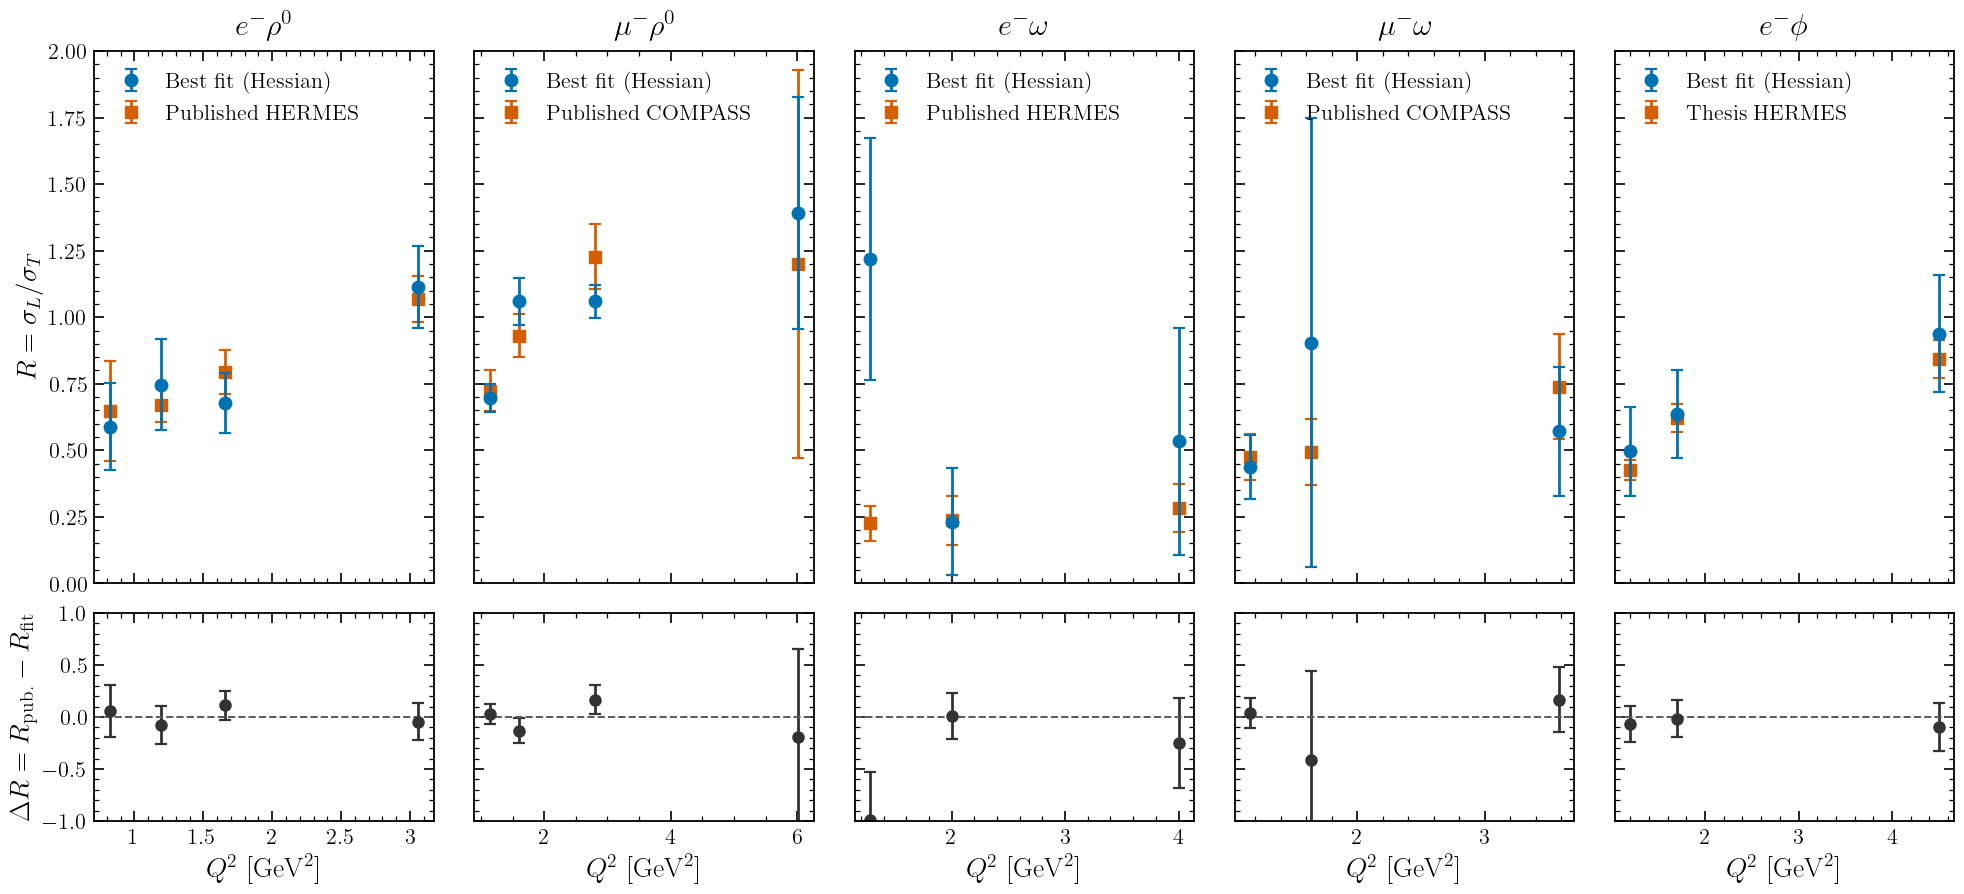

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_R_outputs/RScaling_hessian_rho_omega_phi.png


In [3]:
def extract_R(best):
    if "R" in best.index and "err__R" in best.index:
        return float(best["R"]), float(best["err__R"]), "full covariance propagation"

    # Compatibility fallback for files that contain propagated moment errors
    # but not the dedicated covariance-aware R branch.  This neglects the
    # H4--H0 covariance and is therefore explicitly labelled approximate.
    required = ["H_4_0_0", "H_0_0_0", "err__H_4_0_0", "err__H_0_0_0"]
    if all(name in best.index for name in required):
        h4, h0 = float(best["H_4_0_0"]), float(best["H_0_0_0"])
        s4, s0 = float(best["err__H_4_0_0"]), float(best["err__H_0_0_0"])
        if abs(h0) <= 1e-15:
            raise ZeroDivisionError("H_0_0_0 is zero at the selected minimum")
        ratio = h4 / h0
        error = np.hypot(s4 / h0, h4 * s0 / h0**2)
        warnings.warn("Using diagonal-only R error; the H4--H0 covariance is unavailable")
        return ratio, error, "diagonal approximation"
    raise KeyError("No propagated R uncertainty is available; rerun the Hessian-writing macro")


def compute_R_results():
    rows = []
    for channel in CHANNELS:
        for bin_index, q2 in enumerate(channel["q2"]):
            path = result_file(channel, bin_index)
            frame = read_fit_file(path, TREE_NAME)
            best_index, best, objective = select_best_minimum(
                frame, require_accurate_covariance=REQUIRE_ACCURATE_COVARIANCE
            )
            ratio, error, method = extract_R(best)
            rows.append({
                "channel": channel["key"],
                "bin": bin_index,
                "Q2": q2,
                "R": ratio,
                "R_error": error,
                "uncertainty_method": method,
                "entries": len(frame),
                "best_entry": best_index,
                "objective": float(best[objective]),
                "cov_status": int(best["cov_status"]),
                "file": str(path.resolve()),
            })
    return pd.DataFrame(rows)


def vmd_model(q2, c0, c1, mass):
    return c0 * (q2 / mass) ** c1


def fit_vmd_curve(channel, q2, values, errors):
    model = lambda x, c0, c1: vmd_model(x, c0, c1, channel["mass"])
    return curve_fit(model, q2, values, sigma=errors, absolute_sigma=True,
                     p0=[1.0, 1.0], maxfev=10000)


def plot_R_scaling(results, show_fit_lines=False,
                   output_name="RScaling_hessian_rho_omega_phi.png"):
    n_channels = len(CHANNELS)
    fig = plt.figure(figsize=(24, 10))
    grid = fig.add_gridspec(2, n_channels, height_ratios=[3.2, 1.25],
                            hspace=0.08, wspace=0.12)
    top_axes = [fig.add_subplot(grid[0, index]) for index in range(n_channels)]
    diff_axes = [fig.add_subplot(grid[1, index]) for index in range(n_channels)]
    for ax in top_axes[1:]:
        ax.sharey(top_axes[0])
    for ax in diff_axes[1:]:
        ax.sharey(diff_axes[0])

    for index, channel in enumerate(CHANNELS):
        ax, diff_ax = top_axes[index], diff_axes[index]
        subset = results.loc[results["channel"] == channel["key"]].sort_values("bin")
        q2 = subset["Q2"].to_numpy(dtype=float)
        fitted = subset["R"].to_numpy(dtype=float)
        fitted_error = subset["R_error"].to_numpy(dtype=float)
        ax.errorbar(q2, fitted, yerr=fitted_error, fmt="o", markersize=9,
                    elinewidth=2.0, capsize=4, capthick=1.6,
                    color=COLORS["fit"], label="Best fit (Hessian)", zorder=5)

        published = channel["published"]
        if published is not None:
            published_value, published_error = published[:, 0], published[:, 1]
            ax.errorbar(q2, published_value, yerr=published_error, fmt="s",
                        markersize=8, elinewidth=2.0, capsize=4, capthick=1.6,
                        color=COLORS["official"], label=channel["published_label"])
            if show_fit_lines and len(q2) >= 2:
                q2_curve = np.linspace(max(0.5, 0.8 * q2.min()), 1.1 * q2.max(), 500)
                fit_parameters, _ = fit_vmd_curve(channel, q2, fitted, fitted_error)
                published_parameters, _ = fit_vmd_curve(
                    channel, q2, published_value, published_error
                )
                ax.plot(q2_curve, vmd_model(q2_curve, *fit_parameters, channel["mass"]),
                        color=COLORS["fit"])
                ax.plot(q2_curve,
                        vmd_model(q2_curve, *published_parameters, channel["mass"]),
                        "--", color=COLORS["official"])
            difference = published_value - fitted
            difference_error = np.hypot(published_error, fitted_error)
            diff_ax.errorbar(q2, difference, yerr=difference_error, fmt="o",
                             markersize=8, elinewidth=2.0, capsize=4, capthick=1.6,
                             color=COLORS["neutral"])
        else:
            diff_ax.text(0.5, 0.5, "No external comparison", ha="center", va="center",
                         transform=diff_ax.transAxes, color="0.35")

        diff_ax.axhline(0, ls="--", color="0.35", linewidth=1.4)
        ax.set_title(channel["title"], pad=12)
        ax.tick_params(labelbottom=False)
        diff_ax.set_xlabel(r"$Q^2\ [\mathrm{GeV}^2]$")
        ax.legend(loc="upper left", frameon=False, handlelength=1.5)
        if index > 0:
            ax.tick_params(labelleft=False)
            diff_ax.tick_params(labelleft=False)

    top_axes[0].set_ylabel(r"$R=\sigma_L/\sigma_T$")
    diff_axes[0].set_ylabel(r"$\Delta R=R_{\rm pub.}-R_{\rm fit}$")
    top_axes[0].set_ylim(0, 2)
    diff_axes[0].set_ylim(-1, 1)
    for ax in top_axes + diff_axes:
        ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:g}"))
        style_axis(ax)
    output = FIGURE_DIR / output_name
    save_figure(fig, output)


R_results = compute_R_results()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
display(R_results)
plot_R_scaling(R_results, show_fit_lines=False)
